# DQN
In this Lab, you will implement DQN on cartpole environment

In [362]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import torch.nn as nn
from dataclasses import dataclass
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.distributions import Categorical

In [405]:
def sample_n_trajectories(env: gym.Env, num_trajectories: int, actor, seed, env_stats):
    
    trajectories = {}
    
    obs = []
    next_obs = []
    actions = []
    log_probs = []
    rewards = []
    terminals = []
    for _ in range(num_trajectories):
        trajectory = sample_trajectory(env, actor, seed, env_stats)
        obs.append(trajectory['obs'])
        next_obs.append(trajectory['next_obs'])
        rewards.append(trajectory['rewards'])
        actions.append(trajectory['actions'])
        log_probs.append(trajectory['log_probs'])
        terminals.append(trajectory['terminals'])

    trajectories['obs'] = obs # list of length n, each element is a tensor of size (num_steps_per_trajectory, obs_dim)
    trajectories['next_obs'] = next_obs # list of length n, each element is a tensor of size (num_steps_per_trajectory, obs_dim)
    trajectories['actions'] = actions # list of length n, each element is a tensor of size (num_steps_per_trajectory, action_dim)
    trajectories['log_probs'] = log_probs # list of length n, each element is a tensor of size (num_steps_per_trajectory)
    trajectories['rewards'] = rewards # list of length n, each element is a tensor of size (num_steps_per_trajectory)
    trajectories['terminals'] = terminals # list of length n, each element is a tensor of size (num_steps_per_trajectory)

    return trajectories

    
    
def sample_trajectory(env: gym.Env, actor, seed, env_stats):
    obs = []
    next_obs = []
    actions = []
    log_probs = []
    rewards = []
    terminals = []
    
    ob, _ = env.reset(seed=seed)
    while True:
#         action = env.action_space.sample()
        ob = torch.FloatTensor(ob)
        ob_norm = (ob - env_stats['obs_mean']) / (env_stats['obs_std'] + 1e-8)
        action, log_prob = actor.get_action(ob_norm)
        next_ob, rew, terminated, truncated, info = env.step(action.long().cpu().numpy())
        rollout_done = terminated or truncated
        
        obs.append(ob)
        next_obs.append(torch.FloatTensor(next_ob))
        rewards.append(torch.tensor([rew], dtype=float))
        actions.append(torch.tensor([action], dtype=int))
        log_probs.append(log_prob)
        terminals.append(torch.tensor([rollout_done], dtype=bool))
        
        if rollout_done:
            break
        
        ob = next_ob
    
    trajectory = {}
    trajectory['obs'] = torch.stack(obs, dim=0) # (num_steps_per_trajectory, obs_dim)
    trajectory['next_obs'] = torch.stack(next_obs, dim=0) # (num_steps_per_trajectory, obs_dim)
    trajectory['rewards'] = torch.stack(rewards, dim=0).squeeze(1) # (num_steps_per_trajectory)
    trajectory['actions'] = torch.stack(actions, dim=0) # (num_steps_per_trajectory, action_dim)
    trajectory['log_probs'] = torch.stack(log_probs, dim=0) # (num_steps_per_trajectory)
    trajectory['terminals'] = torch.stack(terminals, dim=0).squeeze(1) # (num_steps_per_trajectory)
    
    return trajectory

## Replay buffer

In [466]:
class ReplayBuffer():
    def __init__(self, capacity: int):
        """
        capacity: int representing the maximum size of the buffer
        """
        self.max_size = capacity
        self.size = 0 # current size of the buffer
        self.ptr = 0  # pointer to the next index to insert data

        self.observations = []
        self.actions = []
        self.rewards = []
        self.next_observations = []
        self.dones = []

    def sample(self, batch_size: int) -> dict:
        """
        Samples a batch of samples randomly from the buffer, each sample is (s, a, r, s', done)
        batch_size: int representing the size of the batch
        return: dictionary containing the batch, each entry is a tensor of shape (batch_size, ...)
        """
        # No need to handle 'dones' here since we are not sampling sequences
        if self.size < batch_size:
            raise ValueError("Not enough samples in the buffer to sample a batch")
        rand_indices = torch.randint(0, self.size, size=(batch_size,))
        return {
            "observations": self.observations[rand_indices],
            "actions": self.actions[rand_indices],
            "rewards": self.rewards[rand_indices],
            "next_observations": self.next_observations[rand_indices],
            "dones": self.dones[rand_indices]
        }

    def insert(
            self,
            obs: torch.Tensor,
            next_obs: torch.Tensor,
            actions: torch.Tensor,
            rewards: torch.Tensor,
            dones: torch.Tensor,
            ):
        """
        Inserts samples into the buffer
        obs: tensor of shape (T, obs_dim)
        next_obs: tensor of shape (T, obs_dim)
        actions: tensor of shape (T, action_dim) or (T,) for discrete actions
        rewards: tensor of shape (T,)
        dones: tensor of shape (T,)
        T is the batch size of the data being inserted
        """

        if not isinstance(self.observations, torch.Tensor):
            self.observations = torch.empty(
                (self.max_size, obs.shape[1]), dtype=obs.dtype)
            if actions.ndim > 1:
                self.actions = torch.empty((self.max_size, actions.shape[1]), dtype=actions.dtype)
            else:
                self.actions = torch.empty((self.max_size), dtype=actions.dtype)
            self.rewards = torch.empty((self.max_size), dtype=rewards.dtype)
            self.next_observations = torch.empty(
                (self.max_size, obs.shape[1]), dtype=obs.dtype
            )
            self.dones = torch.empty((self.max_size), dtype=dones.dtype)

        batch_size = actions.shape[0]
        ## insert into buffer
        if self.ptr + batch_size <= self.max_size:
            self.observations[self.ptr:self.ptr + batch_size] = obs
            self.actions[self.ptr:self.ptr + batch_size] = actions
            self.rewards[self.ptr:self.ptr + batch_size] = rewards
            self.next_observations[self.ptr:self.ptr + batch_size] = next_obs
            self.dones[self.ptr:self.ptr + batch_size] = dones
            self.ptr += batch_size
            self.size = min(self.size + batch_size, self.max_size)
        else:
            overflow = (self.ptr + batch_size) - self.max_size
            idxs_first = self.max_size - self.ptr
            self.observations[self.ptr:self.max_size] = obs[:idxs_first]
            self.actions[self.ptr:self.max_size] = actions[:idxs_first]
            self.rewards[self.ptr:self.max_size] = rewards[:idxs_first]
            self.next_observations[self.ptr:self.max_size] = next_obs[:idxs_first]
            self.dones[self.ptr:self.max_size] = dones[:idxs_first]

            self.observations[:overflow] = obs[idxs_first:]
            self.actions[:overflow] = actions[idxs_first:]
            self.rewards[:overflow] = rewards[idxs_first:]
            self.next_observations[:overflow] = next_obs[idxs_first:]
            self.dones[:overflow] = dones[idxs_first:]

            self.ptr = overflow
            self.size = self.max_size

In [467]:
_str_to_activation = {
    'relu': nn.ReLU(),
    'tanh': nn.Tanh(),
    'leaky_relu': nn.LeakyReLU(),
    'sigmoid': nn.Sigmoid(),
    'selu': nn.SELU(),
    'softplus': nn.Softplus(),
    'identity': nn.Identity(),
    'softmax': nn.Softmax(dim=-1)
}

In [468]:
@dataclass
class MLPConfig:
    n_in: int
    n_out: int
    n_hidden: int = 64
    n_layers: int = 2
    activation: str = 'relu'
    output_activation: str = 'identity'

In [490]:
@dataclass
class DQNAgentConfig:
    ## architecture parameters (same architecture for actor, critic and model)
    architecture: str = 'MLP'
    obs_dim: int = 4
    act_dim: int = 2
    n_hidden: int = 64
    n_layers: int = 2
    activation: str = 'relu'

    ## critic optimization parameters
    critic_lr: float = 1e-2
    critic_optimizer: str = 'adam'
    critic_use_learning_rate_scheduler: bool = True
    critic_lr_scheduler: str = 'linear'

    ## other parameters
    gamma: float = 1
    n_updates: int = 2000
    n_trajectories = 5

    ## DQN parameters
    replay_buffer_size: int = 1000000
    dqn_epsilon: float = 1
    dqn_epsilon_decay: float = 0.5
    dqn_epsilon_start: float = 1.0
    dqn_epsilon_min: float = 0.02
    dqn_batch_size: int = 128
    dqn_tau: float = 0.005
    dqn_warmup_steps: int = 10000
    dqn_done_warmup: bool = False
    dqn_n_updates: int = 10


In [491]:
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        activation = _str_to_activation[config.activation]
        output_activation = _str_to_activation[config.output_activation]

        layers = []
        n_in = config.n_in
        for _ in range(config.n_layers):
            layers.append(nn.Linear(n_in, config.n_hidden))
            layers.append(nn.LayerNorm(config.n_hidden))
            layers.append(activation)
            n_in = config.n_hidden
        layers.append(nn.Linear(config.n_hidden, config.n_out))
        layers.append(output_activation)

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# DQN Agent 

In [492]:
class DQNAgent(nn.Module):
    def __init__(self, config: DQNAgentConfig):
        super().__init__()

        self.config = config

        self.critic, self.critic_optimizer, self.critic_lr_scheduler = self._make_critic()

        self.target_critic, _, _ = self._make_critic()
        self.target_critic.load_state_dict(self.critic.state_dict())

        self.replay_buffer = self._make_replay_buffer()

    def _make_replay_buffer(self):
        """ Creates a replay buffer if the agent is not on-policy.
        Returns:
            ReplayBuffer: An instance of ReplayBuffer with the specified size from the config.
        """
        replay_buffer = ReplayBuffer(self.config.replay_buffer_size)
        return replay_buffer

    
    def _make_critic(self):
        """ Creates the critic network based on the configuration.
        Returns:
            critic (nn.Module): The critic network.
            critic_optimizer (torch.optim.Optimizer): Optimizer for the critic network.
            critic_lr_scheduler (torch.optim.lr_scheduler): Learning rate scheduler for the critic.
        """

        mlp_config = MLPConfig(*[self.config.obs_dim, self.config.act_dim, self.config.n_hidden, self.config.n_layers, 
                    self.config.activation])
        critic = MLP(mlp_config)
        
        if self.config.critic_optimizer == 'adam':
            critic_optimizer = optim.Adam(critic.parameters(), lr=self.config.critic_lr)

        if self.config.critic_use_learning_rate_scheduler:
            critic_lr_scheduler = optim.lr_scheduler.LinearLR(critic_optimizer, 
                start_factor=1.0, end_factor=0.01, total_iters=self.config.n_updates*0.85)
        else:
            critic_lr_scheduler = None

        return critic, critic_optimizer, critic_lr_scheduler
    

    def get_action(self, obs: torch.Tensor) -> torch.Tensor:
        """ Computes the action to take given the observation.
        Args:
            obs (torch.Tensor): The observation from the environment, shape (batch_size, obs_dim).
        Returns:
            action (torch.Tensor): The action to take, shape (batch_size, act_dim).
            log_probs (torch.Tensor): Log probabilities of the actions, shape (batch_size,).
        """
        qa_values = self.critic(obs)## critic gets state and output Q(s,a) for all a
        if torch.rand(1).item() >= self.config.dqn_epsilon:
            action = torch.argmax(qa_values, dim=-1)
        else:
            action = torch.randint(0, 2, ())
        log_probs = torch.tensor(0) #dummy value, not used in algorithm
        return action, log_probs
    

    def _calculate_critic_loss(self, batch: dict, env_stats):
        """ Calculates the critic loss and updates the critic network.
        Args:
            batch (dict): A dictionary containing the batch of data with keys:
                'observations', 'actions', 'rewards', 'next_observations', 'dones'.
            env_stats (dict, optional): Environment statistics.
        Returns:
            loss_critic (float): The computed critic loss.
            avg_sum_q (float): The average sum of Q values for the actions taken in the batch.
        """
        obs_batch = batch['observations']  # batch_size x dim(S)
        actions_batch = batch['actions']
        rewards_batch = batch['rewards']
        next_obs_batch = batch['next_observations']
        dones_batch = batch['dones']
        
        ## calculate target Q values
        with torch.no_grad():
            next_obs_norm = (next_obs_batch - env_stats['obs_mean']) / (env_stats['obs_std'] + 1e-8)
            next_qa_values = self.target_critic(next_obs_norm)  # batch_size x dim(A)
            next_action = torch.argmax(next_qa_values, dim=1)
            next_q_values = next_qa_values[torch.arange(next_action.shape[0]), next_action.long()]  # batch_size,
            target_values = rewards_batch.to(torch.float32) + self.config.gamma * next_q_values * (1 - dones_batch.float())  # batch_size,

        ## calculate critic loss
        obs_norm = (obs_batch - env_stats['obs_mean']) / (env_stats['obs_std'] + 1e-8)
        qa_values = self.critic(obs_norm)  # batch_size x dim(A)
        q_values = qa_values[torch.arange(qa_values.shape[0]), actions_batch] 
        loss_critic = nn.MSELoss()(q_values.to(torch.float32), target_values.to(torch.float32))

        ## update critic
        self.critic_optimizer.zero_grad()
        loss_critic.backward()
        self.critic_optimizer.step()
        
        if self.config.critic_use_learning_rate_scheduler:
            self.critic_lr_scheduler.step()
            
        ## update target critic
        for target_param, param in zip(self.target_critic.parameters(), self.critic.parameters()):
            target_param.data.copy_(self.config.dqn_tau * param.data + 
                                    (1 - self.config.dqn_tau) * target_param.data)
        
        return loss_critic.item(), q_values.mean().item()
    

    def learn(self, data: dict, env_stats: dict = None):
        """ Learns from the collected data.
        Args:
            data (dict): A dictionary containing the collected data with keys:
                'obs', 'actions', 'rewards', 'terminals'.
            env_stats (dict, optional): Environment statistics, such as 'obs_mean' and 'obs_std'.
        Returns:
            meta_data (dict): A dictionary containing metadata about the learning process, such as:
                'loss_critic', 'avg_sum_q', 'avg_sum_rewards'.
        """
        obs = data['obs'] # list of n_trajectories, each is (len_traj x dim(S))
        next_obs = data['next_obs'] # list of n_trajectories, each is (len_traj x dim(S))
        actions = data['actions'] # list of n_trajectories, each is (len_traj x dim(A))
        terminals = data['terminals'] # list of n_trajectories, each is(len_traj,) 
        rewards = data['rewards'] # list of n_trajectories, each is(len_traj,) 
        
        # calculate avg_sum_rewards
        n_traj = len(rewards)
        avg_sum_rewards = []
        for i in range(n_traj):
            r = rewards[i]
            avg_sum_rewards.append(torch.sum(r).item())
        avg_sum_rewards2 = sum(avg_sum_rewards)/len(avg_sum_rewards)
        
        # flatten
        obs_torch = torch.cat(obs, dim=0)
        next_obs_torch = torch.cat(next_obs, dim=0)
        actions_torch = torch.cat(actions, dim=0).squeeze(-1)
        terminals_torch = torch.cat(terminals, dim=0)
        rewards_torch = torch.cat(rewards, dim=0) 
        
        ## get collected batch, save to buffer, sample and update if needed
        self.replay_buffer.insert(obs_torch, next_obs_torch, actions_torch.long(), rewards_torch, terminals_torch)

        if self.replay_buffer.size >= self.config.dqn_warmup_steps:
            self.config.dqn_done_warmup = True

        ## decay epsilon
        eps_decay = (self.config.dqn_epsilon_start - 
            self.config.dqn_epsilon_min) / (self.config.n_updates
                                            *self.config.dqn_epsilon_decay)

        self.config.dqn_epsilon = max(self.config.dqn_epsilon_min, 
                                        self.config.dqn_epsilon - eps_decay)
            
        meta_data = {}
        loss_critic = -1
        avg_q = -1
        if self.config.dqn_done_warmup:
            for _ in range(self.config.dqn_n_updates):
                ## sample a batch from the replay buffer
                batch = self.replay_buffer.sample(self.config.dqn_batch_size)

                ## update the critic
                loss_critic, avg_q = self._calculate_critic_loss(batch, env_stats)

        ## return meta data
        meta_data['loss_critic'] = loss_critic
        meta_data['avg_sum_rewards'] = avg_sum_rewards2
        meta_data['avg_q'] = avg_q
        
        return meta_data

## Now, let's train the agent. 

In [493]:
## environment 
env_name = 'CartPole-v1'
env = gym.make(env_name, render_mode=None)

## agent
agent = DQNAgent(DQNAgentConfig())

# Set random seeds
seed = 10
torch.manual_seed(seed)
np.random.seed(seed)

In [494]:
def get_env_statistics(env, n_steps=2000):
        """
        Get the environment statistics such as mean and standard deviation of observations and rewards.
        Returns:
            A dictionary containing the statistics.
        """
        obs_list = []
        rew_list = []

        ob, _ = env.reset()
        for _ in range(n_steps):
            obs_list.append(torch.FloatTensor(ob))
            action = env.action_space.sample()
            next_ob, rew, terminated, truncated, info = env.step(action)
            rew_list.append(torch.tensor([rew], dtype=float))
            if terminated or truncated:
                ob, _ = env.reset()
            else:
                ob = next_ob

        obs = torch.stack(obs_list, dim=0)
        rewards = torch.stack(rew_list, dim=0)

        obs_mean = obs.mean(dim=0)
        obs_std = obs.std(dim=0)
        rew_mean = rewards.mean()
        rew_std = rewards.std()

        stats = {
            'obs_mean': obs_mean,
            'obs_std': obs_std,
            'rew_mean': rew_mean,
            'rew_std': rew_std,
        }
        
        return stats

In [495]:
env_stats = get_env_statistics(env, n_steps=5000)

In [496]:
## Training
sum_rewards_track = []
for itr in range(agent.config.n_updates):

    ## sampling m trajectories
    trajectories = sample_n_trajectories(env, agent.config.n_trajectories, agent, seed, env_stats)

    ## update the policy
    train_meta_data = agent.learn(trajectories, env_stats)
    
    if itr % 20 == 0:
        print(f"\n********** Iteration {itr} ************")
        avg_q = train_meta_data['avg_q']
        old_eps = agent.config.dqn_epsilon
        agent.config.dqn_epsilon = 0
        eval_trajectories = sample_n_trajectories(env, 10, agent, seed, env_stats)
        rewards = eval_trajectories['rewards'] # list of n_trajectories, each is(len_traj,) 
        # calculate avg_sum_rewards
        n_traj = len(rewards)
        avg_sum_rewards = []
        for i in range(n_traj):
            r = rewards[i]
            avg_sum_rewards.append(torch.sum(r).item())
        avg_sum_rewards2 = sum(avg_sum_rewards)/len(avg_sum_rewards)
        agent.config.dqn_epsilon = old_eps
        print(f'\n iteration {itr} got avg. return of {avg_sum_rewards2} with epsilon of {agent.config.dqn_epsilon} and q_value of {avg_q}')
        sum_rewards_track.append(avg_sum_rewards2)


********** Iteration 0 ************

 iteration 0 got avg. return of 10.0 with epsilon of 0.99902 and q_value of -1

********** Iteration 20 ************

 iteration 20 got avg. return of 10.0 with epsilon of 0.9794200000000004 and q_value of -1

********** Iteration 40 ************

 iteration 40 got avg. return of 10.0 with epsilon of 0.9598200000000008 and q_value of -1

********** Iteration 60 ************

 iteration 60 got avg. return of 10.0 with epsilon of 0.9402200000000012 and q_value of -1

********** Iteration 80 ************

 iteration 80 got avg. return of 10.0 with epsilon of 0.9206200000000015 and q_value of -1

********** Iteration 100 ************

 iteration 100 got avg. return of 10.0 with epsilon of 0.9010200000000019 and q_value of 1.9536454677581787

********** Iteration 120 ************

 iteration 120 got avg. return of 23.0 with epsilon of 0.8814200000000023 and q_value of 2.931532382965088

********** Iteration 140 ************

 iteration 140 got avg. retu


********** Iteration 1140 ************

 iteration 1140 got avg. return of 291.0 with epsilon of 0.02 and q_value of 47.13277816772461

********** Iteration 1160 ************

 iteration 1160 got avg. return of 500.0 with epsilon of 0.02 and q_value of 47.347930908203125

********** Iteration 1180 ************

 iteration 1180 got avg. return of 290.0 with epsilon of 0.02 and q_value of 48.84227752685547

********** Iteration 1200 ************

 iteration 1200 got avg. return of 500.0 with epsilon of 0.02 and q_value of 50.58998107910156

********** Iteration 1220 ************

 iteration 1220 got avg. return of 500.0 with epsilon of 0.02 and q_value of 53.419681549072266

********** Iteration 1240 ************

 iteration 1240 got avg. return of 500.0 with epsilon of 0.02 and q_value of 53.70930862426758

********** Iteration 1260 ************

 iteration 1260 got avg. return of 500.0 with epsilon of 0.02 and q_value of 54.66514587402344

********** Iteration 1280 ************

 iter

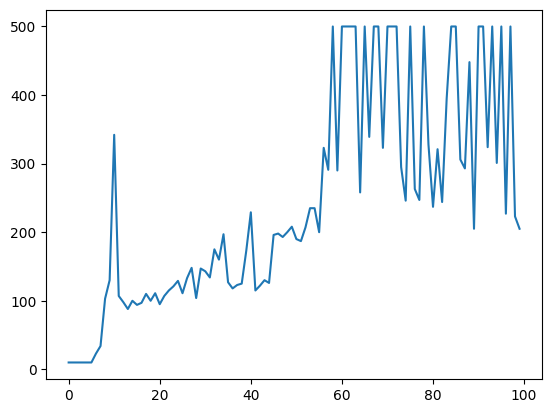

In [497]:
plt.figure
plt.plot(sum_rewards_track)